<>:37: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:37: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\ozhan\AppData\Local\Temp\ipykernel_17356\3215530939.py:37: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  label=f'Eigenvector {i+1} ($\lambda$={eigenvalues[i]:.1f})')


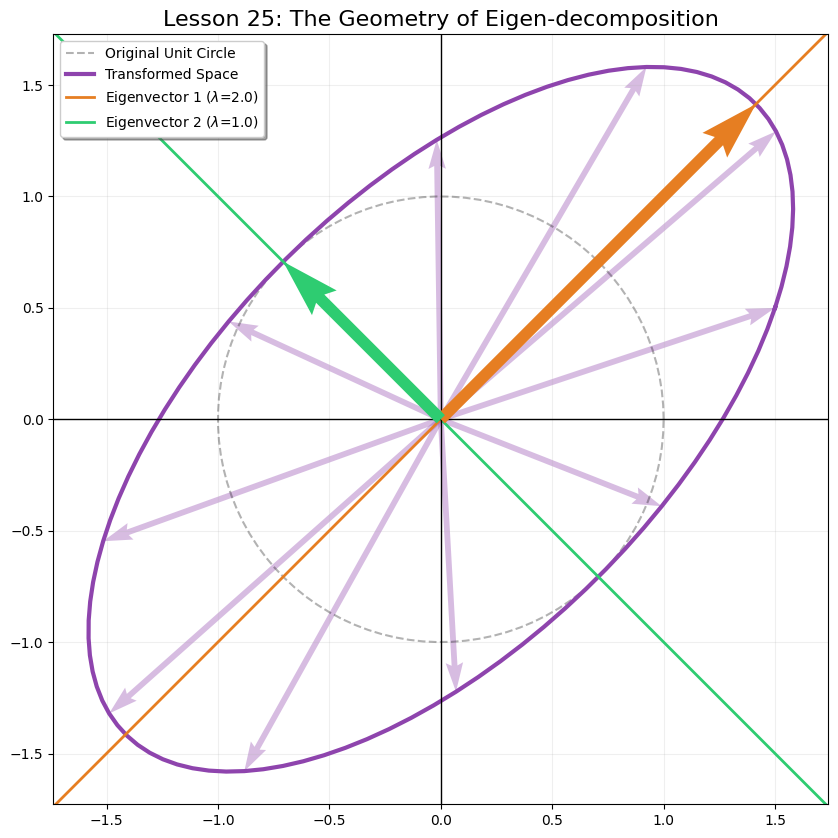

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

def run_eigen_show():
    # Transformasyon matrisi (Asimetrik)
    A = np.array([[1.5, 0.5], 
                  [0.5, 1.5]])
    
    # Özdeğer ve Özvektörleri hesapla
    eigenvalues, eigenvectors = np.linalg.eig(A)
    
    # Birim çember noktaları
    t = np.linspace(0, 2*np.pi, 100)
    circle = np.array([np.cos(t), np.sin(t)])
    transformed_circle = A @ circle

    plt.figure(figsize=(10, 10))
    
    # 1. Orijinal Çember (İnce) ve Dönüşmüş Elips (Kalın)
    plt.plot(circle[0], circle[1], 'k--', alpha=0.3, label='Original Unit Circle')
    plt.plot(transformed_circle[0], transformed_circle[1], color='#8e44ad', lw=3, label='Transformed Space')

    # 2. Rastgele vektörlerin nasıl dönüştüğünü göster (Oklar)
    for i in range(0, 100, 10):
        v = circle[:, i]
        tv = A @ v
        plt.quiver(0, 0, tv[0], tv[1], color='#9b59b6', alpha=0.4, angles='xy', scale_units='xy', scale=1)

    # 3. ÖZVEKTÖRLERİ ÇİZ (Şovun Yıldızları)
    # Özvektör doğrularını (span) sonsuza uzat
    colors = ['#e67e22', '#2ecc71']
    for i in range(len(eigenvalues)):
        ev = eigenvectors[:, i]
        # Doğruyu boydan boya çiz
        plt.axline((0, 0), (ev[0], ev[1]), color=colors[i], lw=2, linestyle='-', 
                    label=f'Eigenvector {i+1} ($\lambda$={eigenvalues[i]:.1f})')
        # Gerçek özvektör okunu çiz
        plt.quiver(0, 0, ev[0]*eigenvalues[i], ev[1]*eigenvalues[i], color=colors[i], 
                   angles='xy', scale_units='xy', scale=1, width=0.015, zorder=10)

    plt.xlim(-3, 3); plt.ylim(-3, 3)
    plt.axhline(0, color='black', lw=1); plt.axvline(0, color='black', lw=1)
    plt.title("Lesson 25: The Geometry of Eigen-decomposition", fontsize=16)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.grid(True, alpha=0.2)
    plt.axis('equal')
    
    if not os.path.exists('../../../assets'): os.makedirs('../../../assets')
    plt.savefig('../../../assets/25_eigenvalues.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    run_eigen_show()